**LSA10 Signal Green Time Parser**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 1: LSA10 SIGNAL GREEN TIME PARSER
# ============================================================
# Purpose:
# - Read LSA10 SI PL / signal-state JSON files
# - Filter representative days and one-hour windows
# - Calculate effective green time per approach
# - Use sgState = 4 as effective green state
# - Save summary + secondwise selected signal data
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA10_719612af-2487-4771-941f-534a4f568272"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA10_green_time_summary.csv"
OUT_XLSX = OUT_DIR / "LSA10_green_time_summary.xlsx"

GREEN_STATE = 4

APPROACH_SIGNAL_MAP = {
    "West":  {"signal_group": "K1", "signal_id": 1},
    "South": {"signal_group": "K5", "signal_id": 19},
    "East":  {"signal_group": "K4", "signal_id": 4},
    "North_East": {"signal_group": "K3", "signal_id": 3},
    "North_West": {"signal_group": "K2", "signal_id": 2},
}

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-03-10",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekday_evening": {
        "date": "2026-03-23",
        "start": "16:00:00",
        "end": "17:00:00",
    },
    "weekend_morning": {
        "date": "2026-03-14",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekend_evening": {
        "date": "2026-03-22",
        "start": "16:00:00",
        "end": "17:00:00",
    },
}

# ============================================================
# PARSE SIGNAL JSON FILES
# ============================================================

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            date_local = str(timestamp_local.date())
            time_local = timestamp_local.time()

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            for approach, info in APPROACH_SIGNAL_MAP.items():
                signal_id = info["signal_id"]

                if signal_id in sig_states:
                    sg_state = sig_states[signal_id]

                    rows.append({
                        "file": json_path.name,
                        "timestamp_local": timestamp_local,
                        "date": date_local,
                        "time": time_local,
                        "approach": approach,
                        "signal_group": info["signal_group"],
                        "signal_id": signal_id,
                        "sg_state": sg_state,
                        "is_green": sg_state == GREEN_STATE,
                        "program": node_info.get("program"),
                        "stage": node_info.get("stage"),
                        "cycCnt": node_info.get("cycCnt"),
                        "stgCnt": node_info.get("stgCnt"),
                        "stgTran": node_info.get("stgTran"),
                    })

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_signal = pd.DataFrame(rows)

print("Parsed signal rows:", len(df_signal))

if df_signal.empty:
    raise ValueError("No signal data parsed. Check SIGNAL_DIR.")

# ============================================================
# FILTER REPRESENTATIVE SCENARIOS
# ============================================================

selected_parts = []

for scenario_name, scenario in SCENARIOS.items():
    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    temp = df_signal[
        (df_signal["date"] == scenario["date"]) &
        (df_signal["time"] >= start_t) &
        (df_signal["time"] < end_t)
    ].copy()

    temp["scenario"] = scenario_name
    temp["window_start"] = scenario["start"]
    temp["window_end"] = scenario["end"]

    selected_parts.append(temp)

df_selected_signal = pd.concat(selected_parts, ignore_index=True)

print("Selected signal rows:", len(df_selected_signal))

if df_selected_signal.empty:
    raise ValueError("No signal data found for selected representative scenarios.")

# ============================================================
# GREEN TIME SUMMARY
# ============================================================

green_summary = (
    df_selected_signal
    .groupby([
        "scenario",
        "date",
        "window_start",
        "window_end",
        "approach",
        "signal_group",
        "signal_id"
    ])
    .agg(
        observed_seconds=("sg_state", "count"),
        green_seconds=("is_green", "sum"),
        cycle_count=("cycCnt", "nunique")
    )
    .reset_index()
)

green_summary["green_minutes"] = green_summary["green_seconds"] / 60
green_summary["green_share_percent"] = (
    green_summary["green_seconds"] / green_summary["observed_seconds"] * 100
)

green_summary["avg_cycle_time_s"] = (
    green_summary["observed_seconds"] / green_summary["cycle_count"]
)

green_summary["avg_green_per_cycle_s"] = (
    green_summary["green_seconds"] / green_summary["cycle_count"]
)

green_summary = green_summary.sort_values(["scenario", "approach"])

# ============================================================
# SAVE OUTPUTS
# ============================================================

green_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

# Excel cannot store timezone-aware datetime values.
# Therefore, convert timestamp_local to string before exporting.
df_selected_signal_excel = df_selected_signal.copy()
df_selected_signal_excel["timestamp_local"] = (
    df_selected_signal_excel["timestamp_local"].astype(str)
)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    green_summary.to_excel(
        writer,
        sheet_name="Green_Time_Summary",
        index=False
    )

    df_selected_signal_excel.to_excel(
        writer,
        sheet_name="Secondwise_Signal_Data",
        index=False
    )

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nGreen time summary:")
print(green_summary)

Found signal JSON files: 320
Parsed signal rows: 16616820
Selected signal rows: 72010
Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_green_time_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_green_time_summary.xlsx

Green time summary:
           scenario        date window_start window_end    approach  \
0   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
1   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
2   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
3   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
4   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
5   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
6   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
7   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
8   weekday_morning 

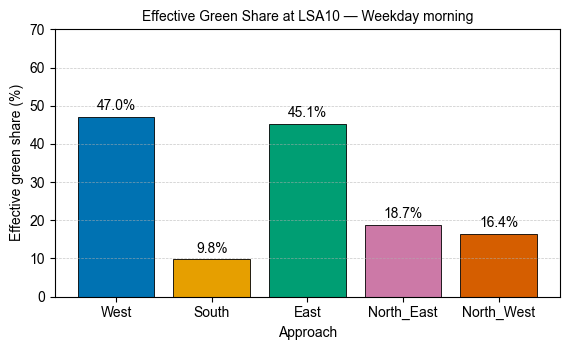

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekday_morning.svg


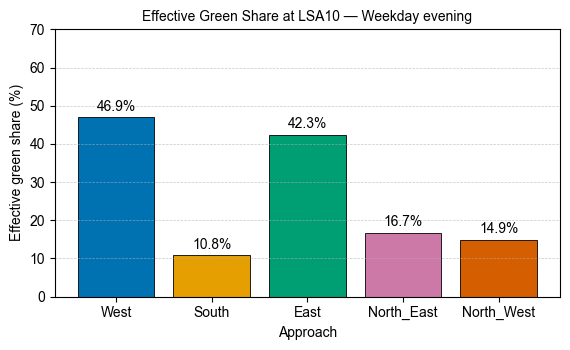

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekday_evening.svg


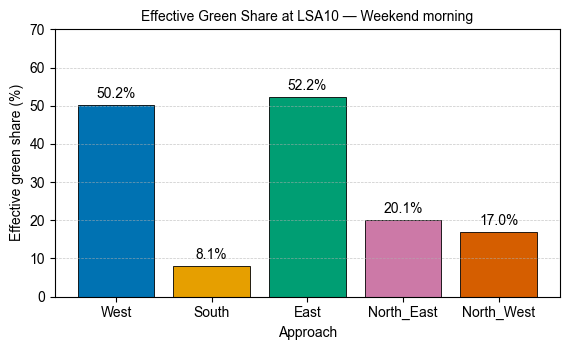

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekend_morning.svg


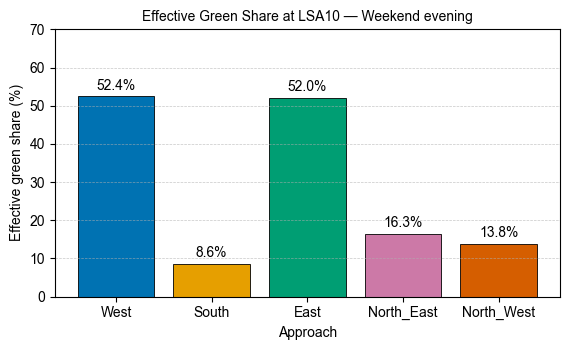

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_weekend_evening.svg


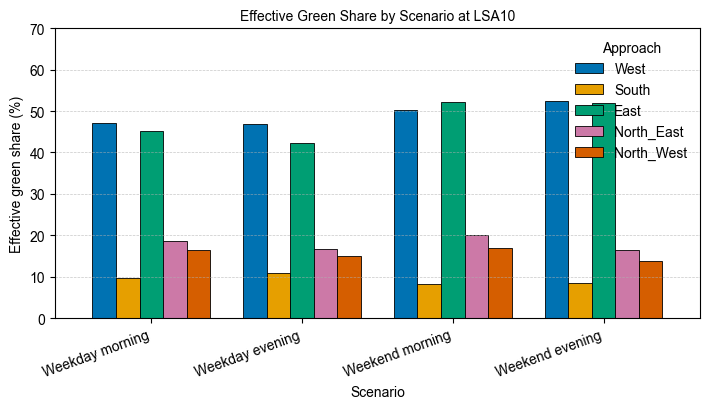

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_grouped_by_scenario.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_green_share_grouped_by_scenario.svg


In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 1B: LSA10 GREEN SHARE BAR CHART
# ============================================================
# Purpose:
# - Read green time summary from Code 1
# - Create thesis-style bar charts for effective green share
# - Use color-blind friendly approach colors
# - Save one grouped chart and four separate scenario charts
# ============================================================

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)

IN_CSV = BASE_DIR / "LSA10_green_time_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

APPROACH_ORDER = ["West", "South", "East", "North_East" , "North_West"]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

# Color-blind friendly approach colors
APPROACH_COLORS = {
    "West": "#0072B2",   # blue
    "South": "#E69F00",  # orange
    "East": "#009E73",   # bluish green
    "North_East": "#CC79A7",  # purple
    "North_West": "#D55E00",
}

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(IN_CSV)

df["approach"] = pd.Categorical(
    df["approach"],
    categories=APPROACH_ORDER,
    ordered=True
)

df["scenario"] = pd.Categorical(
    df["scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

df = df.sort_values(["scenario", "approach"])

# ============================================================
# FIGURE 1: ONE BAR CHART PER SCENARIO
# ============================================================

for scenario in SCENARIO_ORDER:
    label = SCENARIO_LABELS[scenario]
    temp = df[df["scenario"] == scenario].sort_values("approach")

    fig, ax = plt.subplots(figsize=(5.8, 3.6))

    colors = [APPROACH_COLORS[approach] for approach in temp["approach"].astype(str)]

    bars = ax.bar(
        temp["approach"].astype(str),
        temp["green_share_percent"],
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_title(f"Effective Green Share at LSA10 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Effective green share (%)")
    ax.set_ylim(0, 70)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    for bar, value in zip(bars, temp["green_share_percent"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA10_green_share_{scenario}.png"
    out_svg = OUT_DIR / f"LSA10_green_share_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_svg)

# ============================================================
# FIGURE 2: GROUPED BAR CHART
# ============================================================

pivot = df.pivot(
    index="scenario",
    columns="approach",
    values="green_share_percent"
).reindex(SCENARIO_ORDER)

fig, ax = plt.subplots(figsize=(7.2, 4.2))

pivot.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    color=[APPROACH_COLORS[a] for a in APPROACH_ORDER],
    edgecolor="black",
    linewidth=0.6
)

ax.set_title("Effective Green Share by Scenario at LSA10")
ax.set_xlabel("Scenario")
ax.set_ylabel("Effective green share (%)")
ax.set_ylim(0, 70)
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

ax.set_xticklabels(
    [SCENARIO_LABELS[s] for s in SCENARIO_ORDER],
    rotation=20,
    ha="right"
)

ax.legend(
    title="Approach",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

out_png = OUT_DIR / "LSA10_green_share_grouped_by_scenario.png"
out_svg = OUT_DIR / "LSA10_green_share_grouped_by_scenario.svg"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(out_png)
print(out_svg)

*********
**LSA10 Detector Demand Parser**
This code reads the LSA16 detector JSON files, filters the same representative days/time windows, and calculates the observed demand per approach by summing the assigned detector IDs.

In [5]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 2: LSA10 DETECTOR DEMAND PARSER
# ============================================================
# Purpose:
# - Read detector JSON files for LSA10
# - Filter the same representative days and one-hour windows
# - Aggregate detector counts by approach
# - Save detector demand summary for later saturation calculation
# ============================================================

# ============================================================
# SETTINGS
# ============================================================

DETECTOR_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\detector_data_aktuell\LD-LSA10"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA10_detector_demand_summary.csv"
OUT_XLSX = OUT_DIR / "LSA10_detector_demand_summary.xlsx"

APPROACH_DETECTOR_MAP = {
    "West":  [1],
    "South": [31],
    "East":  [3, 4],
    "North_East": [29],
    "North_West": [27, 26],
    
}

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-03-10",
        "file": "2026-03-10.json",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekday_evening": {
        "date": "2026-03-23",
        "file": "2026-03-23.json",
        "start": "16:00:00",
        "end": "17:00:00",
    },
    "weekend_morning": {
        "date": "2026-03-14",
        "file": "2026-03-14.json",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekend_evening": {
        "date": "2026-03-22",
        "file": "2026-03-22.json",
        "start": "16:00:00",
        "end": "17:00:00",
    },
}

# ============================================================
# HELPER FUNCTION
# ============================================================

def extract_count_from_detector(detector):
    """
    Robust count extraction because detector JSON structures can differ slightly.
    Expected common structure:
    detector["reading"]["count"]["value"]
    """
    reading = detector.get("reading", {})

    if isinstance(reading, dict):
        count_block = reading.get("count", {})

        if isinstance(count_block, dict):
            return count_block.get("value", 0) or 0

        if isinstance(count_block, (int, float)):
            return count_block

    return 0


# ============================================================
# PARSE DETECTOR DATA
# ============================================================

secondwise_rows = []
summary_rows = []

for scenario_name, scenario in SCENARIOS.items():
    json_path = DETECTOR_DIR / scenario["file"]

    if not json_path.exists():
        print(f"Missing detector file: {json_path}")
        continue

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    # Store counts per approach
    approach_totals = {
        approach: 0 for approach in APPROACH_DETECTOR_MAP.keys()
    }

    approach_measurements = {
        approach: 0 for approach in APPROACH_DETECTOR_MAP.keys()
    }

    detector_totals = {}

    for timeframe in data.get("timeFrames", []):
        timestamp_str = timeframe.get("timestamp")

        if timestamp_str is None:
            continue

        try:
            timestamp = pd.to_datetime(timestamp_str)
            timestamp_local = timestamp.tz_convert("Europe/Berlin") if timestamp.tzinfo else timestamp

            date_local = str(timestamp_local.date())
            time_local = timestamp_local.time()

            if not (
                date_local == scenario["date"] and
                start_t <= time_local < end_t
            ):
                continue

            detectors = timeframe.get("detectors", [])

            for detector in detectors:
                det_id = detector.get("id")

                if det_id is None:
                    continue

                count = extract_count_from_detector(detector)

                for approach, detector_ids in APPROACH_DETECTOR_MAP.items():
                    if det_id in detector_ids:
                        approach_totals[approach] += count
                        approach_measurements[approach] += 1

                        detector_totals[(approach, det_id)] = (
                            detector_totals.get((approach, det_id), 0) + count
                        )

                        secondwise_rows.append({
                            "scenario": scenario_name,
                            "date": scenario["date"],
                            "window_start": scenario["start"],
                            "window_end": scenario["end"],
                            "timestamp_local": str(timestamp_local),
                            "approach": approach,
                            "detector_id": det_id,
                            "count": count,
                        })

        except Exception as e:
            print(f"Skipped timeframe due to error: {e}")
            continue

    for approach, detector_ids in APPROACH_DETECTOR_MAP.items():
        summary_rows.append({
            "scenario": scenario_name,
            "date": scenario["date"],
            "window_start": scenario["start"],
            "window_end": scenario["end"],
            "approach": approach,
            "detector_ids": "+".join(str(x) for x in detector_ids),
            "demand_veh_per_hour": approach_totals[approach],
            "n_detector_measurements": approach_measurements[approach],
        })

# ============================================================
# CREATE DATAFRAMES
# ============================================================

demand_summary = pd.DataFrame(summary_rows)
detector_detail = pd.DataFrame(secondwise_rows)

if demand_summary.empty:
    raise ValueError("No detector demand data found. Check detector folder and JSON structure.")

demand_summary = demand_summary.sort_values(["scenario", "approach"])

# ============================================================
# SAVE OUTPUTS
# ============================================================

demand_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    demand_summary.to_excel(writer, sheet_name="Detector_Demand_Summary", index=False)
    detector_detail.to_excel(writer, sheet_name="Detector_Detail", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nDetector demand summary:")
print(demand_summary)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_detector_demand_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_detector_demand_summary.xlsx

Detector demand summary:
           scenario        date window_start window_end    approach  \
7   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
8   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
9   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
6   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
5   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
2   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
3   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
4   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
1   weekday_morning  2026-03-10     08:00:00   09:00:00       South   
0   weekday_morning 

**************
**LSA10 Capacity and Saturation Calculation**

combines green time (Code 1) + detector demand (Code 2)
calculates: 
 capacity = green_seconds / 2
saturation = demand / capacity

In [6]:
from pathlib import Path
import pandas as pd

# ============================================================
# CODE 3: LSA10 SATURATION CALCULATION
# ============================================================
# Purpose:
# - Merge green time summary and detector demand
# - Calculate capacity and saturation per approach
# - Save final result table
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)

GREEN_FILE = BASE_DIR / "LSA10_green_time_summary.csv"
DEMAND_FILE = BASE_DIR / "LSA10_detector_demand_summary.csv"

OUT_CSV = BASE_DIR / "LSA10_saturation_summary.csv"
OUT_XLSX = BASE_DIR / "LSA10_saturation_summary.xlsx"

# ============================================================
# LOAD DATA
# ============================================================

green = pd.read_csv(GREEN_FILE)
demand = pd.read_csv(DEMAND_FILE)

# ============================================================
# MERGE DATA
# ============================================================

df = pd.merge(
    green,
    demand,
    on=["scenario", "date", "window_start", "window_end", "approach"],
    how="inner"
)

# ============================================================
# CALCULATIONS
# ============================================================

# Capacity (veh/h)
df["capacity_veh_per_hour"] = df["green_seconds"] / 2

# Saturation degree
df["saturation"] = df["demand_veh_per_hour"] / df["capacity_veh_per_hour"]

# Clean formatting
df["saturation"] = df["saturation"].round(2)
df["capacity_veh_per_hour"] = df["capacity_veh_per_hour"].round(1)

# Optional: classification (nice for interpretation)
def classify_saturation(x):
    if x < 0.7:
        return "Low"
    elif x < 0.9:
        return "Moderate"
    elif x <= 1.0:
        return "High"
    else:
        return "Over-saturated"

df["saturation_level"] = df["saturation"].apply(classify_saturation)

# Sort nicely
df = df.sort_values(["scenario", "approach"])

# ============================================================
# SAVE OUTPUT
# ============================================================

df.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Saturation_Summary", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nFinal saturation results:")
print(df)

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_saturation_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\LSA10_saturation_summary.xlsx

Final saturation results:
           scenario        date window_start window_end    approach  \
0   weekday_evening  2026-03-23     16:00:00   17:00:00        East   
1   weekday_evening  2026-03-23     16:00:00   17:00:00  North_East   
2   weekday_evening  2026-03-23     16:00:00   17:00:00  North_West   
3   weekday_evening  2026-03-23     16:00:00   17:00:00       South   
4   weekday_evening  2026-03-23     16:00:00   17:00:00        West   
5   weekday_morning  2026-03-10     08:00:00   09:00:00        East   
6   weekday_morning  2026-03-10     08:00:00   09:00:00  North_East   
7   weekday_morning  2026-03-10     08:00:00   09:00:00  North_West   
8   weekday_morning  2026-03-10     08:00:00   09:00:00       South   
9   weekday_morning  2026-03-

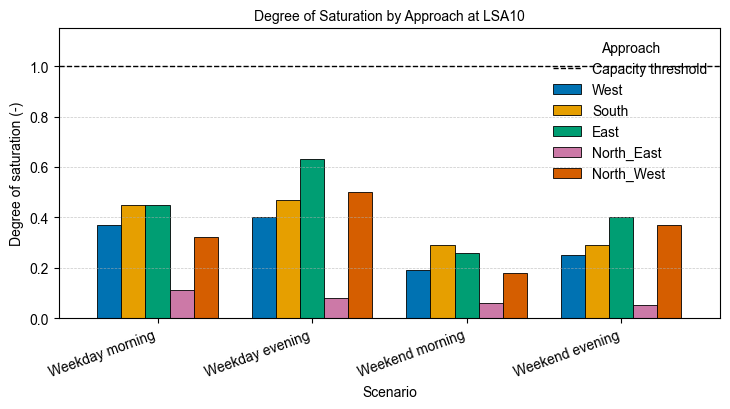

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_grouped_bar.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_grouped_bar.svg


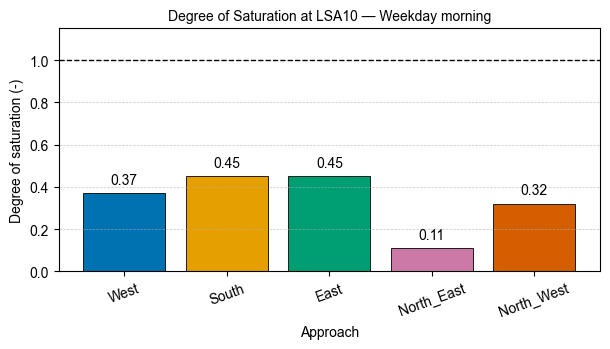

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekday_morning.svg


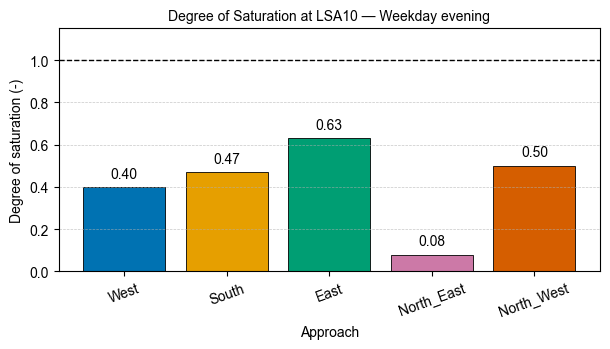

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekday_evening.svg


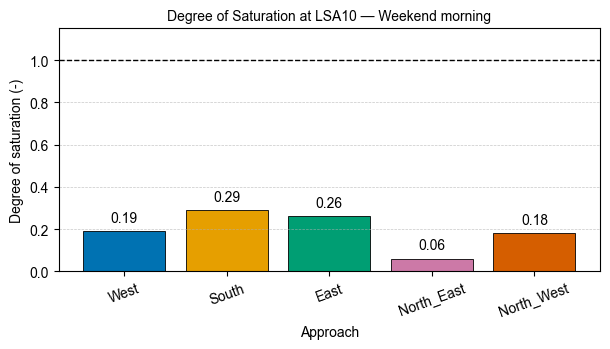

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekend_morning.svg


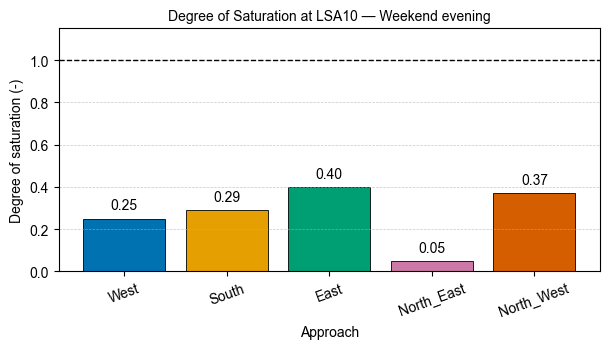

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_saturation_weekend_evening.svg


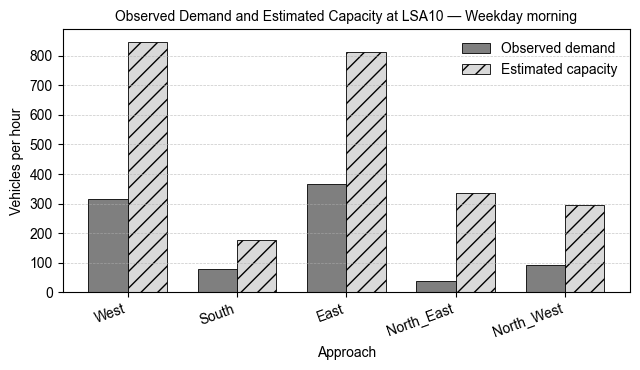

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekday_morning.svg


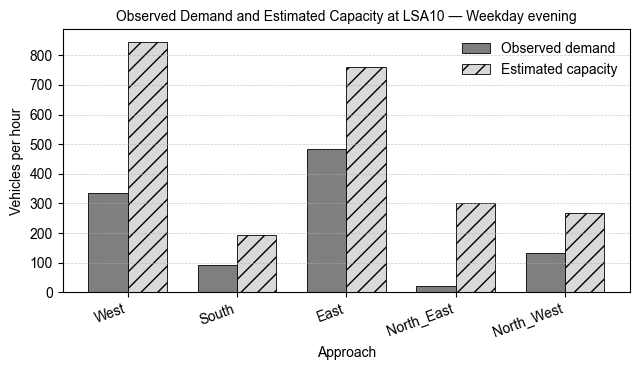

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekday_evening.svg


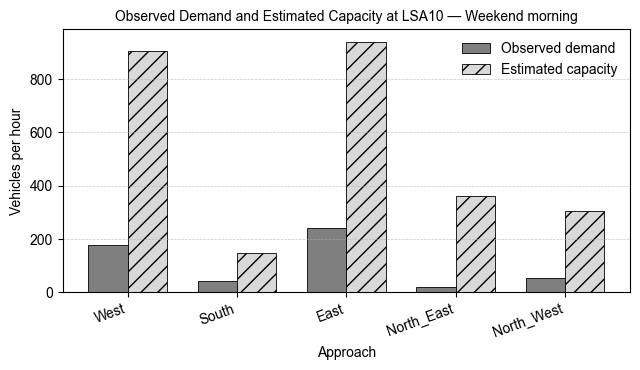

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekend_morning.svg


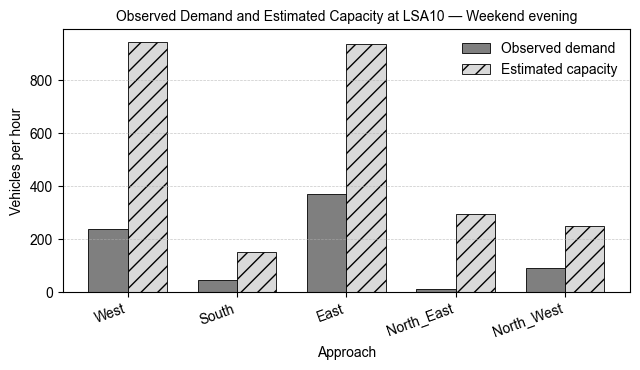

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation\figures\LSA10_demand_capacity_weekend_evening.svg


In [12]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CODE 4: LSA10 SATURATION RESULT FIGURES
# ============================================================
# Purpose:
# - Read final saturation summary
# - Create academic thesis-style figures
# - Plot saturation degree and demand-capacity comparison
# - Handles duplicate scenario-approach rows safely
# ============================================================

# ============================================================
# THESIS FIGURE STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA10_saturation"
)

IN_CSV = BASE_DIR / "LSA10_saturation_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

APPROACH_ORDER = ["West", "South", "East", "North_East", "North_West"]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

# Color-blind friendly approach colors
APPROACH_COLORS = {
    "West": "#0072B2",
    "South": "#E69F00",
    "East": "#009E73",
    "North_East": "#CC79A7",
    "North_West": "#D55E00",
}

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(IN_CSV)

# Remove possible spaces
df["scenario"] = df["scenario"].astype(str).str.strip()
df["approach"] = df["approach"].astype(str).str.strip()

# Keep only approaches that are defined in the order
df = df[df["approach"].isin(APPROACH_ORDER)].copy()

df["approach"] = pd.Categorical(
    df["approach"],
    categories=APPROACH_ORDER,
    ordered=True
)

df["scenario"] = pd.Categorical(
    df["scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

df = df.sort_values(["scenario", "approach"])

# Check duplicates
duplicates = (
    df.groupby(["scenario", "approach"], observed=False)
    .size()
    .reset_index(name="n")
)

duplicates = duplicates[duplicates["n"] > 1]

if not duplicates.empty:
    print("Warning: duplicate scenario-approach rows found. Using mean values in pivot tables.")
    print(duplicates)

# ============================================================
# FIGURE 1: GROUPED SATURATION BAR CHART
# ============================================================

pivot_sat = df.pivot_table(
    index="scenario",
    columns="approach",
    values="saturation",
    aggfunc="mean",
    observed=False
).reindex(SCENARIO_ORDER)

pivot_sat = pivot_sat.reindex(columns=APPROACH_ORDER)

fig, ax = plt.subplots(figsize=(7.4, 4.2))

pivot_sat.plot(
    kind="bar",
    ax=ax,
    width=0.78,
    color=[APPROACH_COLORS[a] for a in pivot_sat.columns],
    edgecolor="black",
    linewidth=0.6
)

ax.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label="Capacity threshold"
)

ax.set_title("Degree of Saturation by Approach at LSA10")
ax.set_xlabel("Scenario")
ax.set_ylabel("Degree of saturation (-)")
ax.set_ylim(0, max(1.15, df["saturation"].max() + 0.15))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

ax.set_xticklabels(
    [SCENARIO_LABELS[s] for s in SCENARIO_ORDER],
    rotation=20,
    ha="right"
)

ax.legend(
    title="Approach",
    frameon=False,
    loc="upper right"
)

plt.tight_layout()

out_png = OUT_DIR / "LSA10_saturation_grouped_bar.png"
out_svg = OUT_DIR / "LSA10_saturation_grouped_bar.svg"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_svg, bbox_inches="tight")
plt.show()

print("Saved:")
print(out_png)
print(out_svg)

# ============================================================
# FIGURE 2: ONE SATURATION BAR CHART PER SCENARIO
# ============================================================

for scenario in SCENARIO_ORDER:
    temp = (
        df[df["scenario"] == scenario]
        .groupby("approach", observed=False)
        .agg(saturation=("saturation", "mean"))
        .reindex(APPROACH_ORDER)
        .dropna()
        .reset_index()
    )

    label = SCENARIO_LABELS[scenario]

    fig, ax = plt.subplots(figsize=(6.2, 3.6))

    colors = [APPROACH_COLORS[a] for a in temp["approach"].astype(str)]

    bars = ax.bar(
        temp["approach"].astype(str),
        temp["saturation"],
        color=colors,
        edgecolor="black",
        linewidth=0.6
    )

    ax.axhline(
        y=1.0,
        color="black",
        linestyle="--",
        linewidth=1.0
    )

    ax.set_title(f"Degree of Saturation at LSA10 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Degree of saturation (-)")
    ax.set_ylim(0, max(1.15, temp["saturation"].max() + 0.15))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    ax.tick_params(axis="x", rotation=20)

    for bar, value in zip(bars, temp["saturation"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.03,
            f"{value:.2f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA10_saturation_{scenario}.png"
    out_svg = OUT_DIR / f"LSA10_saturation_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_svg)

# ============================================================
# FIGURE 3: DEMAND VS CAPACITY PER SCENARIO
# ============================================================

for scenario in SCENARIO_ORDER:
    temp = (
        df[df["scenario"] == scenario]
        .groupby("approach", observed=False)
        .agg(
            demand_veh_per_hour=("demand_veh_per_hour", "mean"),
            capacity_veh_per_hour=("capacity_veh_per_hour", "mean")
        )
        .reindex(APPROACH_ORDER)
        .dropna()
        .reset_index()
    )

    label = SCENARIO_LABELS[scenario]

    x = np.arange(len(temp))
    width = 0.36

    fig, ax = plt.subplots(figsize=(6.5, 3.8))

    ax.bar(
        x - width / 2,
        temp["demand_veh_per_hour"],
        width,
        label="Observed demand",
        color="#7F7F7F",
        edgecolor="black",
        linewidth=0.6
    )

    ax.bar(
        x + width / 2,
        temp["capacity_veh_per_hour"],
        width,
        label="Estimated capacity",
        color="#D9D9D9",
        edgecolor="black",
        linewidth=0.6,
        hatch="//"
    )

    ax.set_title(f"Observed Demand and Estimated Capacity at LSA10 — {label}")
    ax.set_xlabel("Approach")
    ax.set_ylabel("Vehicles per hour")
    ax.set_xticks(x)
    ax.set_xticklabels(temp["approach"].astype(str), rotation=20, ha="right")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

    ax.legend(frameon=False)

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA10_demand_capacity_{scenario}.png"
    out_svg = OUT_DIR / f"LSA10_demand_capacity_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_svg)